# Notebook 2: Do two different protein clusters co-localize?

In [ ]:
%pip install git+https://github.com/bobiac/bobiac-tools.git
%pip install matplotlib
%pip install numpy
%pip install scikit-image
%pip install scipy
%pip install tifffile
%pip install imagecodecs
%pip install pandas
%pip install seaborn

## Overview

In this notebook, we will learn how to assess whether two proteins co-localize.

### Dataset
Our data consists of fluorescence images with five channels:
| Channel | Staining | Staining Description |
|---------|---------|----------------|
| 0 | Hoechst | Nuclear stain |
| 1 | Phalloidin | F-actin stain; whole cell marker |
| 2 | Protein A | Spot pattern |
| 3 | Protein B | Spot pattern |
| 4 | Protein C | Spot pattern |

***

## 0. Importing libraries

***

## 2. Load image, mask and spot table
First, we load all the data that we will need for this notebook.

### Visualy inspect the images, masks and spots
To be sure that the data we are workin with is corrects, we visualise it here.

Using the `focus` attribute in `overlay` we can zoom in to view single objects.

***

## 3. Make An Analysis Plan

### Question
Do Protein A spots co-localize with Protein B spots?

### Approach 
Answering this question is very similar to answering the question of if spots are clustered. Instead of finding nearest neighbours for each point within its *own* dataset, we find the nearest neighbours of points in datasset A to points in dataset B.

### Workflow

#### 1. Generate a reference for comparison
Randomly distributed set of points inside each cell's cytoplasm. We will call this the **random dataset**, which we will compare to our **protein datasets**.

#### 2. Measure the nearest neighbor distance
For every spot in dataset A, identify the closest spot in dataset B and measure the distance.

#### 3. Calculate the average nearest neighbour distance
Average the two distances across all spots in the cell.

#### 4. Calculate the Clark-Evans Index
Calculate the ratio of the average A-B distance compared to the A-random distance. 
    - **Ratio = 1:** Spots in dataset B and the spots in the random dataset are both distributed independently of spots in dataset A
    - **Ratio < 1:** Spots in dataset A co-localise with spots in dataset B
    - **Ratio > 1:** Spots in dataset A and B avoid each other  

#### 5. Calculate the p-value of the Clark-Evans Index
Calculate the p-value using a comparison of multiple random patterns.

#### 6. Calculate the reverse direction of comparison
Measure the distance of every spot in dataset B to dataset A, then repeat the analysis. The two directions are not interchangeable. If set B is much denser than A, every A point will happen to be near some B point even at random, making A→B appear co-localized by chance. Measuring B→A guards against this: if B is merely dense everywhere rather than specifically clustering around A, most B points will still be far from A and the ratio will stay near 1. True mutual co-localization produces small ratios in both directions.

***

## 4. Assemble Datasets

### Generate random point distribution
As before, we focus on one cell to illustrate the principles. First, we need to generate two random set of points, one each as a random distribution of the points of protien A and B (same number of points).

***

## 5. Calculate Nearest Neighbour Distances
We calculate the nearest neighbour distances from 
* protein A spots to protein B spots
* protein B spots to protein A spots
* protein A spots to randomised B spots
* protien B spots to randomised A spots

***

## 6. Calculate Clark-Evans Indices

Now we can calculate our Clark-Evans indices.

***

## 7. Repeat Steps 4-6 with Multiple Random Patterns
As before, we need to compare to multiple random patterns.  

***

## 8. Per-cell Colocalization Measurements

### ✍️ Exercise: Summarise the per-cell co-localisation analysis as a function

To make processing individual cells simpler, we can summarise our above analysis in a function called `CrossNN`.
The function should have the following features:

**Parameters**
spots_A, spots_B : (n, 2) numpy arrays
    Spot coordinates in (row, col) / (y, x) order.
mask : 2D numpy array
    Label mask where each cell is identified by a unique integer ID.
cell_id : int
    ID of the cell in mask that both spot sets belong to.
n_repeats : int
    Number of CSR simulations to run.

**Returns**
dict with keys:
    nn_AtoB, nn_BtoA : float
        Observed mean cross-NN distance in each direction.
    nn_random_AtoB, nn_random_BtoA : float
        Mean of simulated cross-NN distances under CSR.
    ce_AtoB, ce_BtoA : float
        Cross Clark-Evans index (observed / random). < 1 indicates
        co-localization, > 1 indicates avoidance.
    pval_AtoB, pval_BtoA : float
        Fraction of simulations with cross-NN <= observed.
        Small values indicate significant co-localization.


In [41]:
def CrossNN(spots_A, spots_B, mask, cell_id, n_repeats):
    """
    Test whether two sets of spots are more co-localized than expected under
    CSR using cross nearest-neighbor distances.

    For each point in A, the nearest neighbor in B is found (and vice versa).
    The observed mean cross-NN distances are compared to a null distribution
    where both sets are independently randomized within the cell mask.

    The two directions (A→B and B→A) can differ when the sets have different
    sizes: a small set is always close to a large one even by chance.

    Parameters
    ----------
    spots_A, spots_B : (n, 2) numpy arrays
        Spot coordinates in (row, col) / (y, x) order.
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID.
    cell_id : int
        ID of the cell in mask that both spot sets belong to.
    n_repeats : int
        Number of CSR simulations to run.

    Returns
    -------
    dict with keys:
        nn_AtoB, nn_BtoA : float
            Observed mean cross-NN distance in each direction.
        nn_random_AtoB, nn_random_BtoA : float
            Mean of simulated cross-NN distances under CSR.
        ce_AtoB, ce_BtoA : float
            Cross Clark-Evans index (observed / random). < 1 indicates
            co-localization, > 1 indicates avoidance.
        pval_AtoB, pval_BtoA : float
            Fraction of simulations with cross-NN <= observed.
            Small values indicate significant co-localization.
    """
    n_A, n_B = spots_A.shape[0], spots_B.shape[0]

    # observed cross-NN distances
    nn_AtoB = KDTree(spots_B).query(spots_A, k=1)[0].mean()
    nn_BtoA = KDTree(spots_A).query(spots_B, k=1)[0].mean()

    sims_AtoB, sims_BtoA = [], []
    for _ in range(n_repeats):
        rnd_A = random_points_in_mask(mask, cell_label=cell_id, n=n_A)
        rnd_B = random_points_in_mask(mask, cell_label=cell_id, n=n_B)
        sims_AtoB.append(KDTree(rnd_B).query(spots_A, k=1)[0].mean())
        sims_BtoA.append(KDTree(rnd_A).query(spots_B, k=1)[0].mean())

    sims_AtoB = np.array(sims_AtoB)
    sims_BtoA = np.array(sims_BtoA)

    return {
        'nn_AtoB':        nn_AtoB,
        'nn_BtoA':        nn_BtoA,
        'nn_random_AtoB': sims_AtoB.mean(),
        'nn_random_BtoA': sims_BtoA.mean(),
        'ce_AtoB':        nn_AtoB / sims_AtoB.mean(),
        'ce_BtoA':        nn_BtoA / sims_BtoA.mean(),
        'pval_AtoB':      (sims_AtoB <= nn_AtoB).mean(),
        'pval_BtoA':      (sims_BtoA <= nn_BtoA).mean(),
    }


In [42]:
spots_A = df_spots.loc[(df_spots['channel']==0) & (df_spots['label_cell']==cell_id)][['y', 'x']].to_numpy()
spots_B = df_spots.loc[(df_spots['channel']==1) & (df_spots['label_cell']==cell_id)][['y', 'x']].to_numpy()
CrossNN(spots_A=spots_A, spots_B=spots_B, mask=mask, cell_id=cell_id, n_repeats=10)

{'nn_AtoB': np.float64(1.9696171301040926),
 'nn_BtoA': np.float64(3.3610265155268935),
 'nn_random_AtoB': np.float64(6.603303167119867),
 'nn_random_BtoA': np.float64(7.246996725683177),
 'ce_AtoB': np.float64(0.2982775559831174),
 'ce_BtoA': np.float64(0.46378198345467697),
 'pval_AtoB': np.float64(0.0),
 'pval_BtoA': np.float64(0.0)}

### Repeat measurements for all cells
So far, we have focussed on one single cell. Of course, we need to analyse all cells. 

In [ ]:
n_repeats = 10

results = []
for cell_id in df_cell['label'].unique():
    spots_A = df_spots.loc[(df_spots['channel']==0) & (df_spots['label_cell']==cell_id)][['y', 'x']].to_numpy()
    spots_B = df_spots.loc[(df_spots['channel']==1) & (df_spots['label_cell']==cell_id)][['y', 'x']].to_numpy()

    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(CrossNN(spots_A=spots_A, spots_B=spots_B, mask=mask, cell_id=cell_id, n_repeats=n_repeats))

df_cell = pd.concat([df_cell, pd.DataFrame(results)], axis=1)
df_cell

,area,label,count,nnd_observed,nnd_random,clark_evans,p_value,nn_AtoB,nn_BtoA,nn_random_AtoB,nn_random_BtoA,ce_AtoB,ce_BtoA,pval_AtoB,pval_BtoA
0,813.0,6,4,6.386375,5.841208,1.183311,0.5,0.500000,7.040192,2.107554,8.423400,0.237242,0.835790,0.0,0.3
1,12236.0,7,61,6.311969,6.802401,0.931204,0.0,2.043728,5.711784,5.774096,7.714179,0.353948,0.740427,0.0,0.0
2,3897.0,9,19,6.835503,6.882408,1.000944,0.3,1.645157,5.123184,3.874341,7.456071,0.424629,0.687116,0.0,0.1
3,4029.0,10,20,6.454970,6.530639,1.002395,0.4,3.593114,5.122364,4.420370,7.349626,0.812854,0.696956,0.0,0.0
4,2124.0,11,10,6.214888,6.674236,0.941602,0.2,1.700877,8.957093,3.213349,8.099835,0.529316,1.105836,0.0,0.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,10682.0,104,53,5.318296,7.620668,0.699892,0.0,1.852648,4.067538,5.544458,7.544323,0.334144,0.539152,0.0,0.0
90,6146.0,106,30,5.234533,6.652371,0.792979,0.0,2.548677,5.406141,4.760794,8.318264,0.535347,0.649912,0.0,0.0
91,6745.0,107,33,6.339555,6.902593,0.925239,0.2,1.698497,4.073663,4.703580,7.472306,0.361107,0.545168,0.0,0.0
92,7501.0,108,37,7.490188,7.352563,1.020644,0.7,1.837516,4.194518,4.806957,7.910465,0.382262,0.530249,0.0,0.0


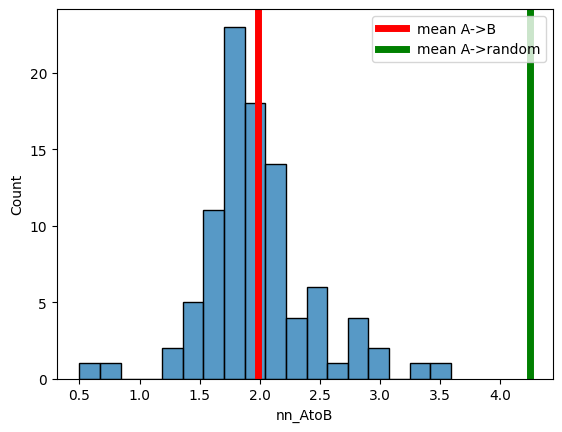

In [56]:
sns.histplot(
    df_cell,
    x='nn_AtoB',
)
plt.axvline(df_cell['nn_AtoB'].mean(), c='red', lw=5, label='mean A->B')
plt.axvline(df_cell['nn_random_AtoB'].mean(), c='green', lw=5, label='mean A->random')
plt.legend()

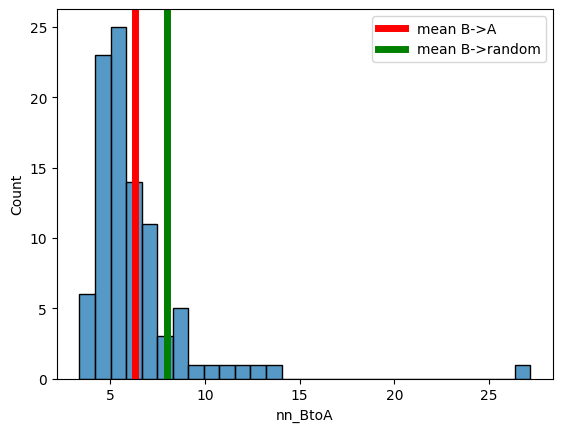

In [57]:
sns.histplot(
    df_cell,
    x='nn_BtoA',
)
plt.axvline(df_cell['nn_BtoA'].mean(), c='red', lw=5, label='mean B->A')
plt.axvline(df_cell['nn_random_BtoA'].mean(), c='green', lw=5, label='mean B->random')
plt.legend()

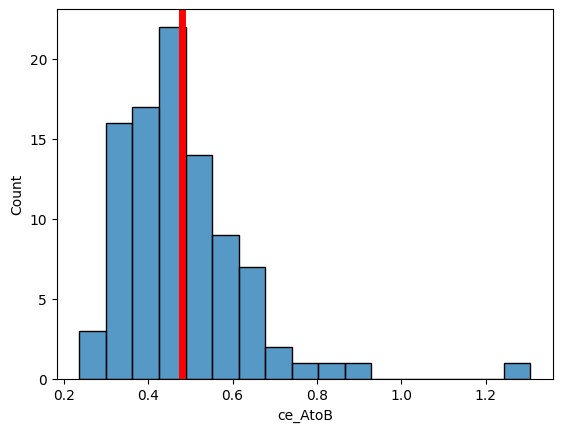

In [51]:
sns.histplot(
    df_cell,
    x='ce_AtoB',
)
plt.axvline(df_cell['ce_AtoB'].mean(), c='red', lw=5)

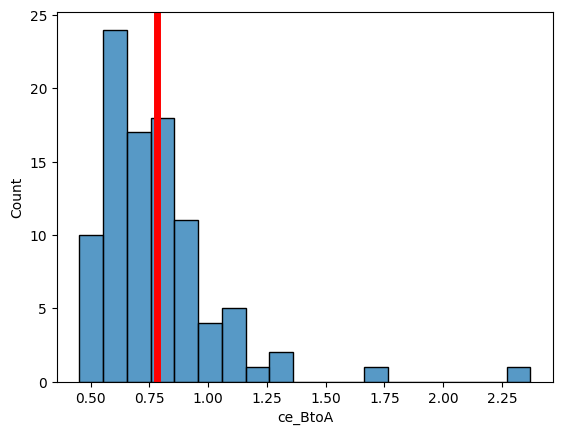

In [52]:
sns.histplot(
    df_cell,
    x='ce_BtoA',
)
plt.axvline(df_cell['ce_BtoA'].mean(), c='red', lw=5)

**Interpretation:** Almost all of protein A associates with protein B but not vice versa. 